# Import all libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 


In [9]:
df = pd.read_csv(r"C:\Users\attafuro\Desktop\Cancer_Risk_Assessment\data\cancer-risk-factors.csv")
df.head()

,Patient_ID,Cancer_Type,Age,Gender,Smoking,Alcohol_Use,Obesity,Family_History,Diet_Red_Meat,Diet_Salted_Processed,...,Physical_Activity,Air_Pollution,Occupational_Hazards,BRCA_Mutation,H_Pylori_Infection,Calcium_Intake,Overall_Risk_Score,BMI,Physical_Activity_Level,Risk_Level
0,LU0000,Breast,68,0,7,2,8,0,5,3,...,4,6,3,1,0,0,0.398696,28.0,5,Medium
1,LU0001,Prostate,74,1,8,9,8,0,0,3,...,1,3,3,0,0,5,0.424299,25.4,9,Medium
2,LU0002,Skin,55,1,7,10,7,0,3,3,...,1,8,10,0,0,6,0.605082,28.6,2,Medium
3,LU0003,Colon,61,0,6,2,2,0,6,2,...,6,4,8,0,0,8,0.318449,32.1,7,Low
4,LU0004,Lung,67,1,10,7,4,0,6,3,...,9,10,9,0,0,5,0.524358,25.1,2,Medium


## Identification 
Patient Id : Unique Id
Cancer Type : The kind of canacer they have 

## General Chracteristics
Gender
Age
BMI

## Lifestyle and Environmental Factors
Smoking
Alcohol Type
Obesity
Diet Red Meat
Diet Salted Processed
Fruit Veg Intake
Physical Activity 
Air Pollution
Occupational Hazards 
Calcuim Intake 

## Medical Factors
Family History
BRCA Mutation
H_Pylori_Infection

## Engineereed (Calculated Score)
Overall Risk Score
Risk Level

## What to Predict 
Risk Level


In [11]:
df.Cancer_Type.value_counts()

Cancer_Type
Lung        527
Breast      460
Colon       418
Prostate    305
Skin        290
Name: count, dtype: int64

## Exploratory Data Analysis

In [14]:
risk_counts = df["Risk_Level"].value_counts()
risk_counts

Risk_Level
Medium    1574
Low        324
High       102
Name: count, dtype: int64

<Axes: xlabel='Risk_Level'>

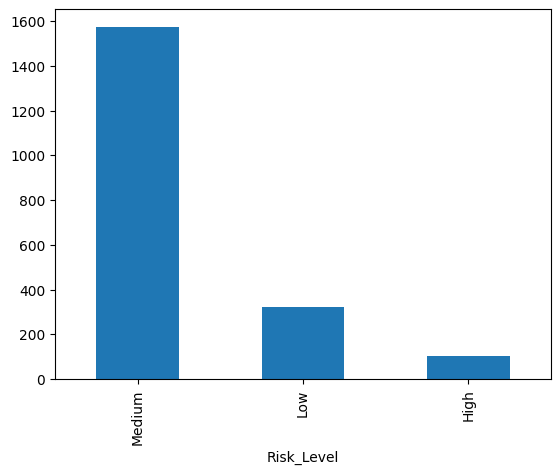

In [16]:
df["Risk_Level"].value_counts().plot(kind='bar')

In [19]:
df["Risk_Level"].value_counts()/len(df)*100

Risk_Level
Medium    78.7
Low       16.2
High       5.1
Name: count, dtype: float64

## The data is highky imbalanced

Meduim - 78.7%
Low - 16.2%
High - 5.1%



In [20]:
df.Gender.value_counts()

Gender
0    1022
1     978
Name: count, dtype: int64

<Axes: xlabel='Cancer_Type'>

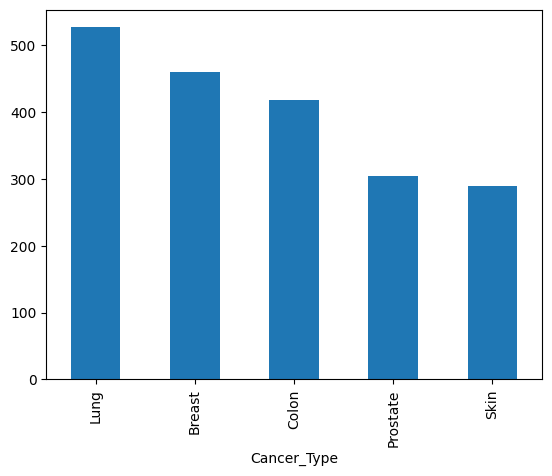

In [21]:
df.Cancer_Type.value_counts().plot(kind='bar')

In [23]:
gender_cancer_counts = df.groupby(['Gender','Cancer_Type']).size().reset_index(name='Patient_Count')

gender_cancer_counts['Gender'] = gender_cancer_counts['Gender'].map({0:'Female',1:'Male'})

print(gender_cancer_counts)



   Gender Cancer_Type  Patient_Count
0  Female      Breast            455
1  Female       Colon            197
2  Female        Lung            238
3  Female        Skin            132
4    Male      Breast              5
5    Male       Colon            221
6    Male        Lung            289
7    Male    Prostate            305
8    Male        Skin            158


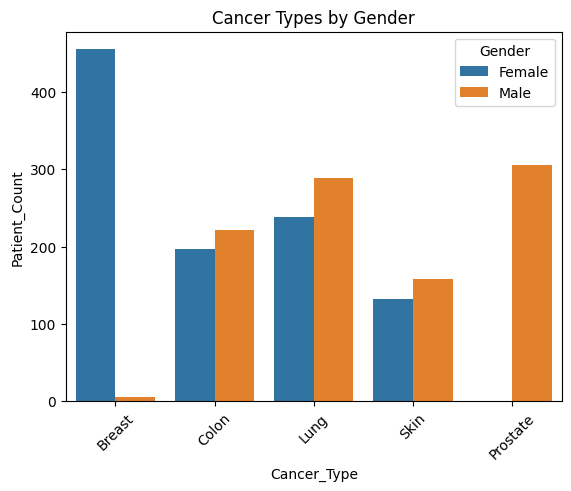

In [25]:
sns.barplot(data=gender_cancer_counts,x='Cancer_Type',y='Patient_Count',hue='Gender')
plt.title('Cancer Types by Gender')
plt.xticks(rotation=45)
plt.show()

# Find all patient under 35

In [27]:
young_patient = df[df['Age'] < 35]
young_patient

,Patient_ID,Cancer_Type,Age,Gender,Smoking,Alcohol_Use,Obesity,Family_History,Diet_Red_Meat,Diet_Salted_Processed,...,Physical_Activity,Air_Pollution,Occupational_Hazards,BRCA_Mutation,H_Pylori_Infection,Calcium_Intake,Overall_Risk_Score,BMI,Physical_Activity_Level,Risk_Level
420,BR0020,Skin,32,0,1,3,8,0,5,1,...,0,4,4,0,0,3,0.283988,34.2,1,Low
433,BR0033,Lung,25,0,8,6,5,0,3,5,...,5,8,9,0,0,3,0.550154,28.9,8,Medium
454,BR0054,Lung,29,0,8,6,7,0,3,0,...,0,7,2,0,0,2,0.412898,23.9,6,Medium
468,BR0068,Lung,32,0,8,2,0,0,1,9,...,0,8,2,0,0,2,0.338060,23.9,2,Medium
495,BR0095,Breast,31,0,1,9,10,0,8,5,...,4,0,4,0,0,0,0.421680,28.2,6,Medium
585,BR0185,Lung,34,0,6,8,5,0,3,1,...,3,8,4,0,1,2,0.516405,27.0,3,Medium
593,BR0193,Breast,34,0,5,1,10,1,1,8,...,5,4,5,1,0,4,0.468496,27.3,0,Medium
621,BR0221,Lung,25,0,7,10,6,0,2,7,...,4,7,10,0,0,0,0.583443,27.9,4,Medium
698,BR0298,Lung,34,0,8,0,2,0,0,0,...,1,7,5,0,1,1,0.246356,29.7,9,Low


In [39]:
count_young = (df['Age'] < 35).sum()
print(f'Number of patient under 35: {count_young}')

Number of patient under 35: 9


In [40]:
young_cancer_types = df[df["Age"] < 35]['Cancer_Type'].value_counts()
young_cancer_types

Cancer_Type
Lung      6
Breast    2
Skin      1
Name: count, dtype: int64

This shows which cancer tyes appear among young cases and how many cases of each.

In [43]:
##Finding out which factors highly contribute to high risk level 

## Select only the numerical columns

numeric_columns = df.select_dtypes(include='number').columns

# Compute the mean of each numeric feature per risk level 

risk_means = df.groupby('Risk_Level')[numeric_columns].mean().T
risk_means

Risk_Level,High,Low,Medium
Age,63.745098,63.685185,63.125794
Gender,0.509804,0.493827,0.486658
Smoking,7.519608,2.845679,5.479670
Alcohol_Use,7.519608,2.984568,5.296061
Obesity,7.274510,4.824074,6.118170
Family_History,0.205882,0.138889,0.205210
Diet_Red_Meat,7.362745,3.972222,5.299238
Diet_Salted_Processed,7.039216,2.888889,4.747776
Fruit_Veg_Intake,3.911765,5.666667,4.841169
Physical_Activity,4.921569,3.669753,4.027319


## Insights

1.Heavy smokers are more likely to be at high risk.

2.High alcohol use is strongly linked to high risk.

3.High red meat consumption is highly linked to high risk.

4.High intake of salt / processed foods is strongly linked to high risk. 

5.Jobs with more hazardious exposures push risk higher

6.High risk patients eat significantly fewer fruits and veggies.


In [ ]:
## Foc